In [1]:
"""
Title: Variational AutoEncoder
Author: [fchollet](https://twitter.com/fchollet)
Date created: 2020/05/03
Last modified: 2024/04/24
Description: Convolutional Variational AutoEncoder (VAE) trained on MNIST digits.
Accelerator: GPU
"""

"""
## Setup
"""

import os

os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import tensorflow as tf
import keras
from keras import ops
from keras import layers
import matplotlib.pyplot as plt

I0000 00:00:1785783288.102700     414 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785783288.369071     414 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785783289.975375     414 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:

"""
## Create a sampling layer
"""


class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator(1337)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        epsilon = keras.random.normal(shape=(batch, dim), seed=self.seed_generator)
        return z_mean + ops.exp(0.5 * z_log_var) * epsilon

In [3]:
"""
## Build the encoder
"""

latent_dim = 2

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

I0000 00:00:1785783291.317382     414 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9507 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4080 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 14, 14,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 7, 7, 64)  │     18,496 │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 3136)      │          0 │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16)        │     50,192 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 2)         │         34 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 2)         │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 69,076 (269.83 KB)

 Trainable params: 69,076 (269.83 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
"""
## Build the decoder
"""

latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3136)           │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 64)     │        36,928 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 32)     │        18,464 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 28, 28, 1)      │           289 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,089 (254.25 KB)

 Trainable params: 65,089 (254.25 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
"""
## Define the VAE as a `Model` with a custom `train_step`
"""


class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = ops.mean(
                ops.sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
            kl_loss = ops.mean(ops.sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        self.total_loss_tracker.update_state(total_loss)
        return {
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
            "total_loss": self.total_loss_tracker.result(),
        }


In [6]:
"""
## Train the VAE
"""

(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
mnist_digits = np.concatenate([x_train, x_test], axis=0)
mnist_digits = np.expand_dims(mnist_digits, -1).astype("float32") / 255

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
history = vae.fit(mnist_digits, epochs=5, batch_size=128)  # epochs reduced from 30 for a quicker first pass

Epoch 1/5


I0000 00:00:1785783294.523491     463 service.cc:153] XLA service 0x798a24038c00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1785783294.523516     463 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4080 Laptop GPU, Compute Capability 8.9 (Driver: 13.3.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.24.0)
I0000 00:00:1785783294.556489     463 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.


I0000 00:00:1785783294.821263     463 cuda_dnn.cc:461] Loaded cuDNN version 92400
I0000 00:00:1785783294.849733     463 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_3550__.15


  1/547 ━━━━━━━━━━━━━━━━━━━━ 56:47 6s/step - kl_loss: 0.0024 - reconstruction_loss: 543.6606 - total_loss: 543.6631

 12/547 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - kl_loss: 0.0572 - reconstruction_loss: 519.2743 - total_loss: 519.3315  

...

479/547 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - kl_loss: 6.2652 - reconstruction_loss: 156.3379 - total_loss: 162.6031

499/547 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - kl_loss: 6.2645 - reconstruction_loss: 156.4271 - total_loss: 162.6916

518/547 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - kl_loss: 6.2634 - reconstruction_loss: 156.4254 - total_loss: 162.6889

539/547 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - kl_loss: 6.2627 - reconstruction_loss: 156.4534 - total_loss: 162.7162

547/547 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - kl_loss: 6.2654 - reconstruction_loss: 156.4285 - total_loss: 162.6940


<Figure size 640x480 with 0 Axes>

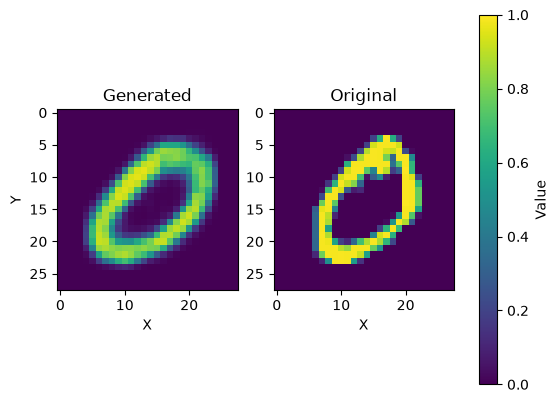

In [7]:
sample = tf.convert_to_tensor(tf.expand_dims(mnist_digits[1],axis=0))
mean, log_var, encoding = encoder(sample,training=False)
creative_figure = decoder(encoding,training=False)

data = [creative_figure.numpy()[0,:,:].sum(axis=2),
        mnist_digits[1].sum(axis=2)]

plt.figure()
fig, axes = plt.subplots(1, 2)

im = axes[0].imshow(data[0], cmap='viridis', vmin=0, vmax=1)
fig.colorbar(im, ax=axes, label="Value")
axes[0].set_title("Generated")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

im = axes[1].imshow(data[1], cmap='viridis', vmin=0, vmax=1)
axes[1].set_title("Original")
axes[1].set_xlabel("X")
#axes[1].ylabel("Y")

plt.savefig("./vae_generated.png")
plt.show()

<Figure size 640x480 with 0 Axes>

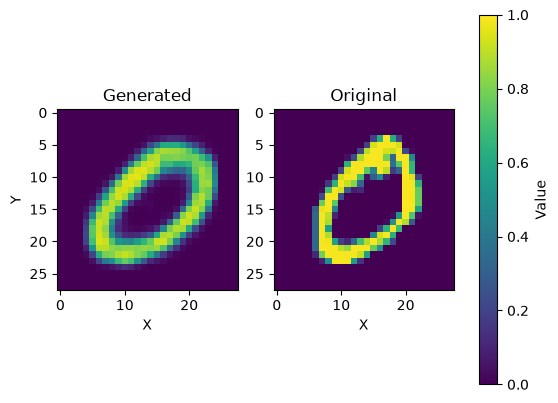

<Figure size 640x480 with 0 Axes>

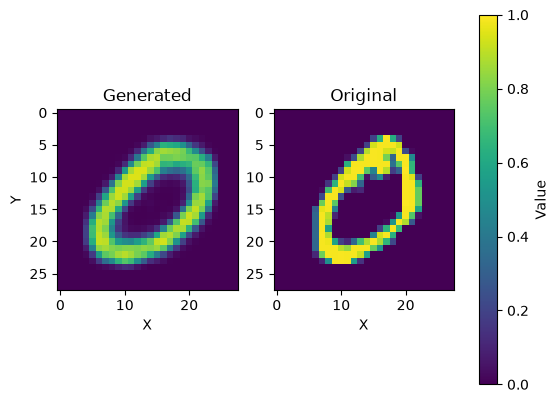

<Figure size 640x480 with 0 Axes>

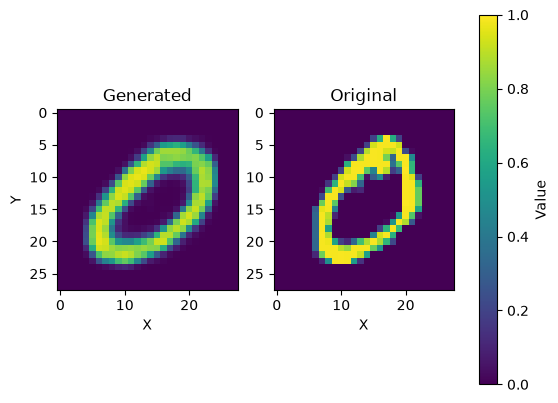

<Figure size 640x480 with 0 Axes>

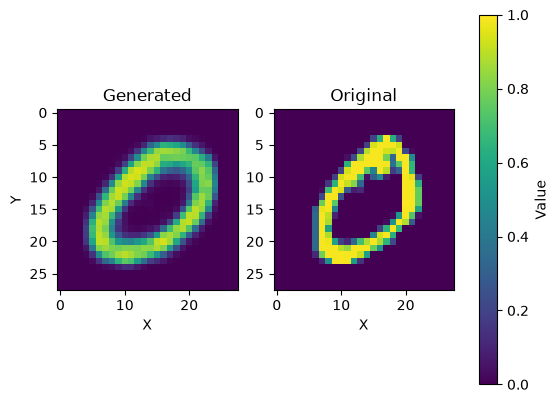

<Figure size 640x480 with 0 Axes>

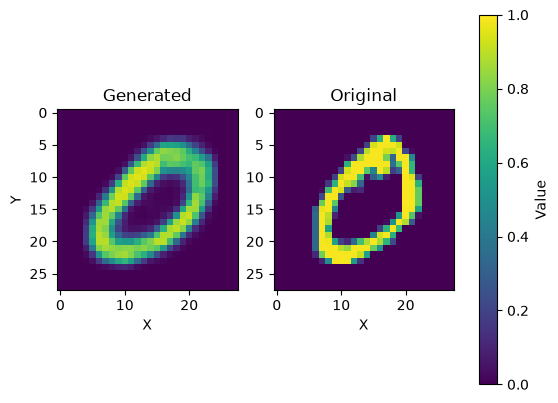

In [8]:
c = 0
original_data = mnist_digits[1].sum(axis=2)

while c < 5:
    noise = np.random.uniform(low=-0.3, high=0.3, size=encoding.shape)
    creative_figure = decoder(encoding + noise, training=False)

    creative_data = creative_figure.numpy()[0,:,:].sum(axis=2)

    plt.figure()
    fig, axes = plt.subplots(1, 2)

    im = axes[0].imshow(creative_data, cmap='viridis', vmin=0, vmax=1)
    fig.colorbar(im, ax=axes, label="Value")
    axes[0].set_title("Generated")
    axes[0].set_xlabel("X")
    axes[0].set_ylabel("Y")

    im = axes[1].imshow(original_data, cmap='viridis', vmin=0, vmax=1)
    axes[1].set_title("Original")
    axes[1].set_xlabel("X")

    plt.savefig(f"./vae_digit_with_noise_{c}.png")
    plt.show()
    c += 1

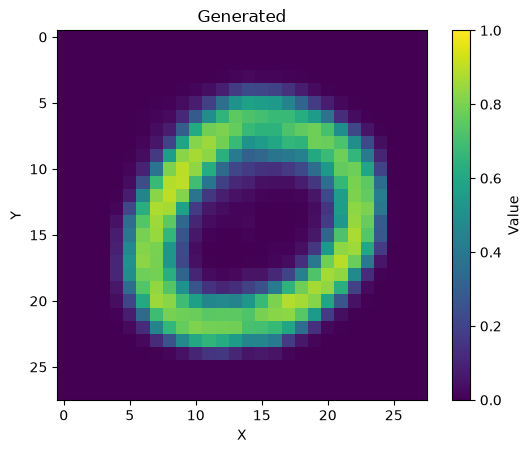

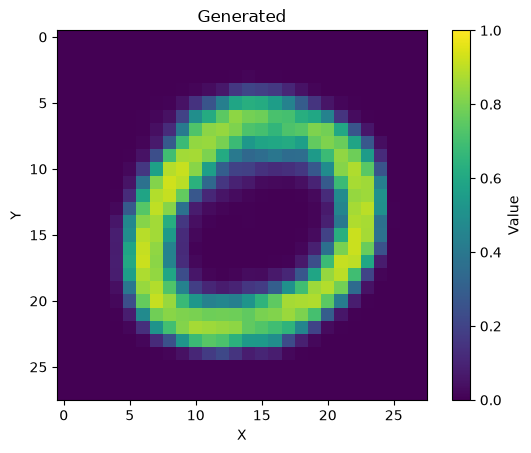

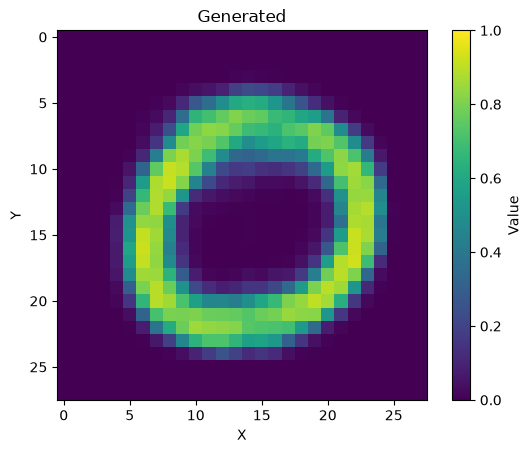

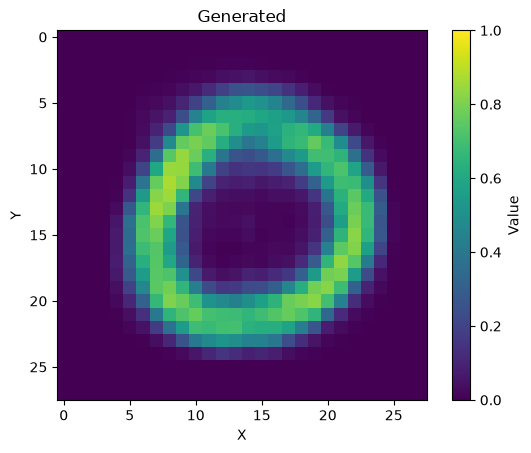

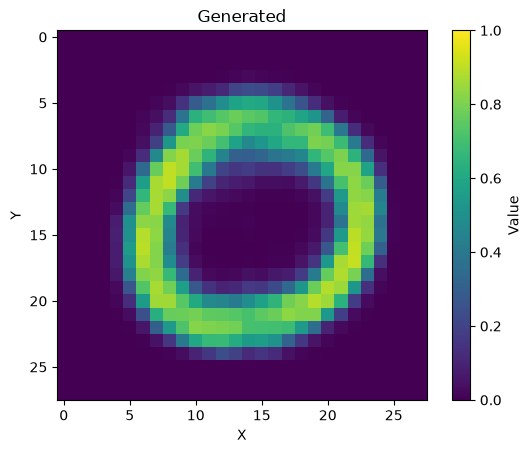

In [9]:
c = 0

while c < 5:
    noise = np.random.uniform(low=0.0, high=1.0, size=encoding.shape)
    creative_figure = decoder(noise, training=False)

    creative_data = creative_figure.numpy()[0,:,:].sum(axis=2)

    fig = plt.figure()
    

    im = plt.imshow(creative_data, cmap='viridis', vmin=0, vmax=1)
    plt.colorbar(im, label="Value")
    plt.title("Generated")
    plt.xlabel("X")
    plt.ylabel("Y")

    plt.savefig(f"./vae_figure_from_noise_{c}.png")
    plt.show()
    c += 1

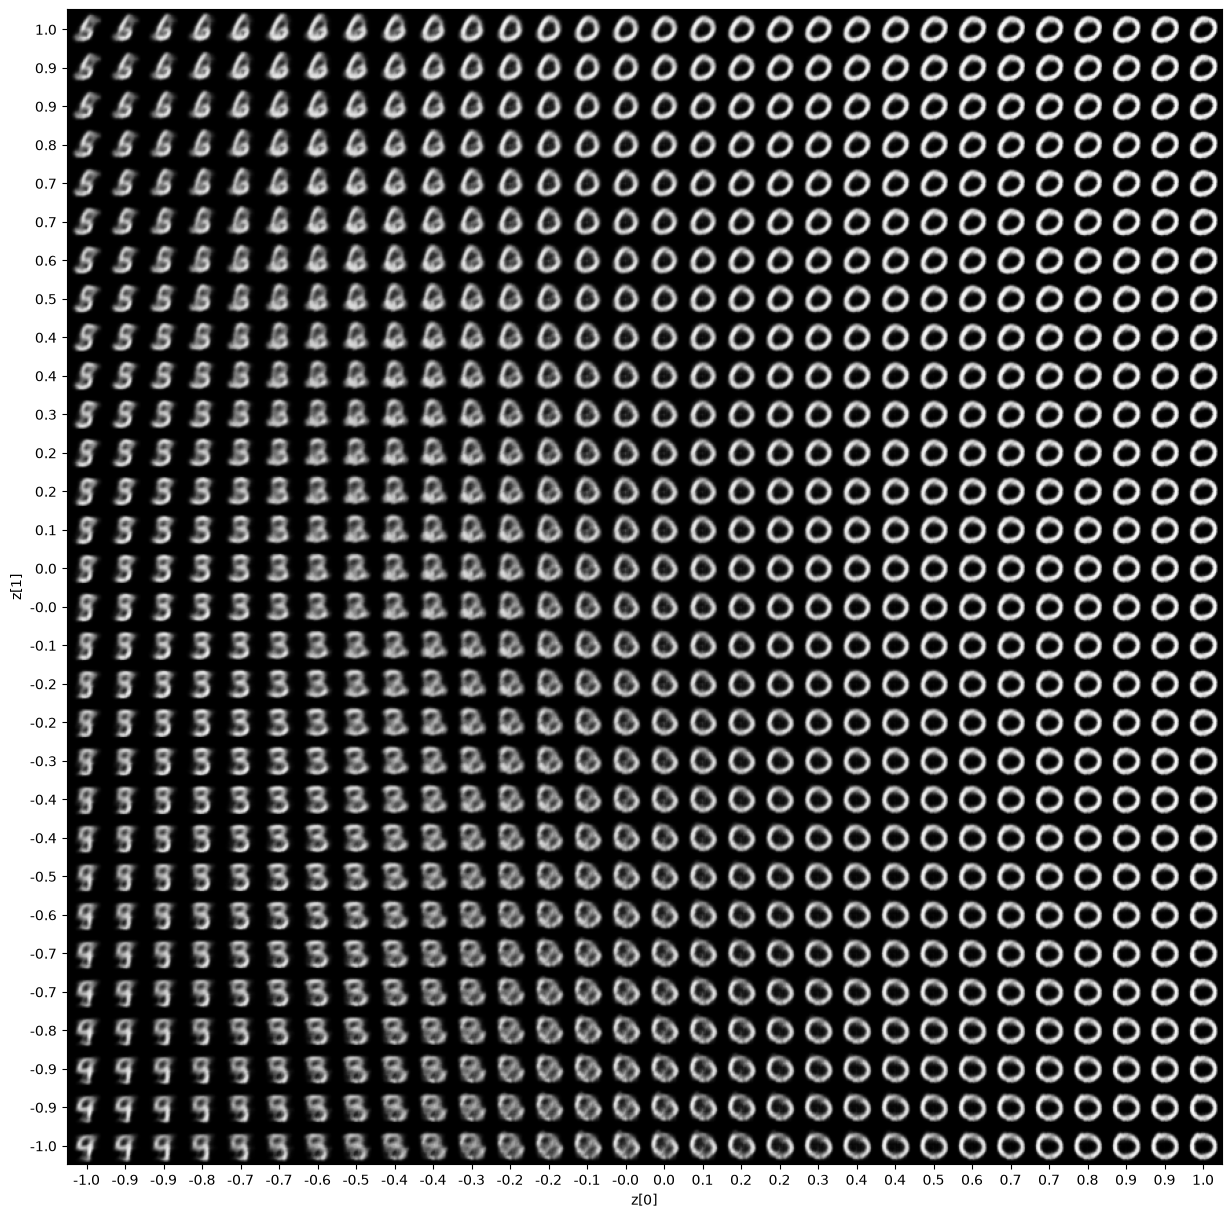

In [10]:

"""
## Display a grid of sampled digits
"""

import matplotlib.pyplot as plt


def plot_latent_space(vae, n=30, figsize=15):
    # display a n*n 2D manifold of digits
    digit_size = 28
    scale = 1.0
    figure = np.zeros((digit_size * n, digit_size * n))
    # linearly spaced coordinates corresponding to the 2D plot
    # of digit classes in the latent space
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = np.array([[xi, yi]])
            x_decoded = vae.decoder.predict(z_sample, verbose=0)
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[
                i * digit_size : (i + 1) * digit_size,
                j * digit_size : (j + 1) * digit_size,
            ] = digit

    plt.figure(figsize=(figsize, figsize))
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    sample_range_x = np.round(grid_x, 1)
    sample_range_y = np.round(grid_y, 1)
    plt.xticks(pixel_range, sample_range_x)
    plt.yticks(pixel_range, sample_range_y)
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.imshow(figure, cmap="Greys_r")
    plt.show()


plot_latent_space(vae)


I0000 00:00:1785783346.594048     464 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_65809__.1


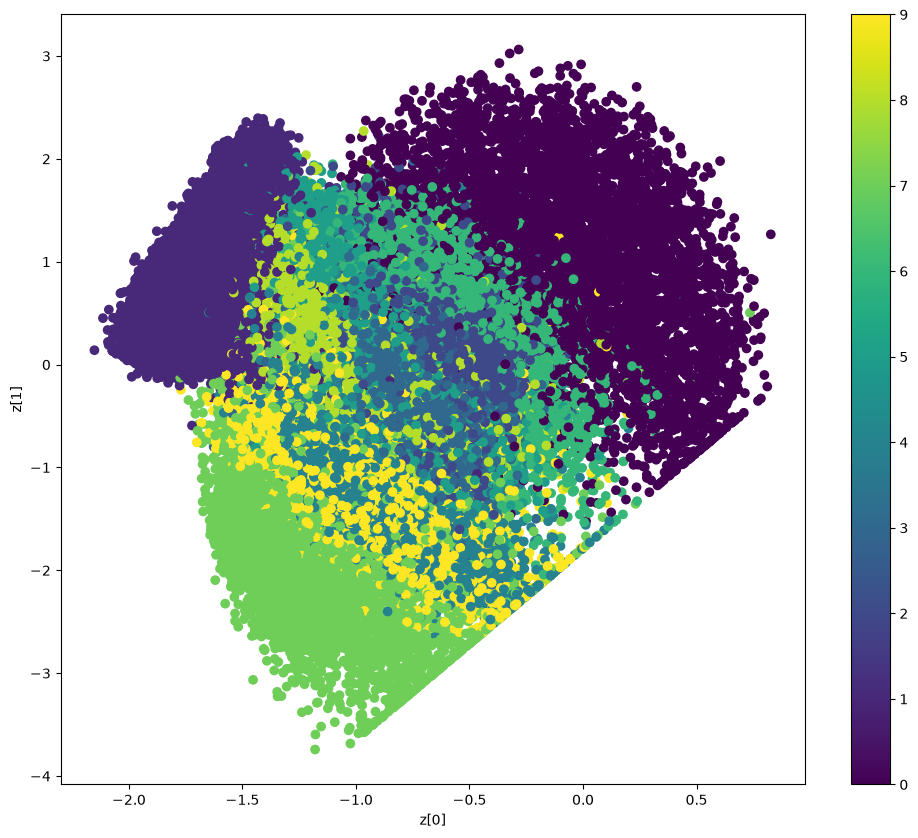

'\n## Relevant Chapters from Deep Learning with Python\n- [Chapter 17: Image generation](https://deeplearningwithpython.io/chapters/chapter17_image-generation)\n'

In [11]:

"""
## Display how the latent space clusters different digit classes
"""


def plot_label_clusters(vae, data, labels):
    # display a 2D plot of the digit classes in the latent space
    z_mean, _, _ = vae.encoder.predict(data, verbose=0)
    plt.figure(figsize=(12, 10))
    plt.scatter(z_mean[:, 0], z_mean[:, 1], c=labels)
    plt.colorbar()
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.show()


(x_train, y_train), _ = keras.datasets.mnist.load_data()
x_train = np.expand_dims(x_train, -1).astype("float32") / 255

plot_label_clusters(vae, x_train, y_train)

"""
## Relevant Chapters from Deep Learning with Python
- [Chapter 17: Image generation](https://deeplearningwithpython.io/chapters/chapter17_image-generation)
"""

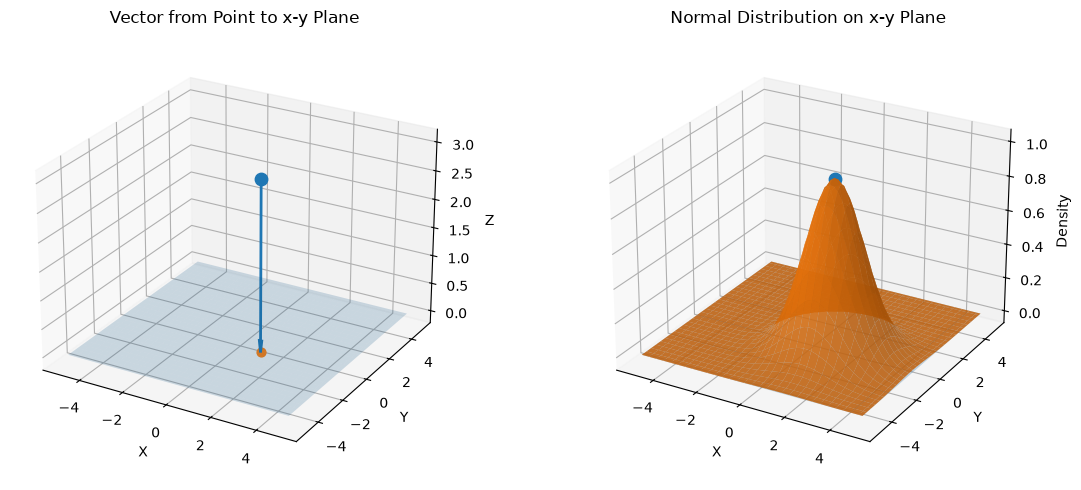

In [12]:
import matplotlib.pyplot as plt

# Create grid for the x-y plane
x = np.linspace(-5, 5, 60)
y = np.linspace(-5, 5, 60)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

# Point above the plane
px, py, pz = 1.5, -1.0, 3.0

# Gaussian distribution centered at the projected point
sigma = 1.2
G = np.exp(-((X - px) ** 2 + (Y - py) ** 2) / (2 * sigma ** 2))

# Create figure
fig = plt.figure(figsize=(12, 5))

# -------------------------------
# Left subplot: vector to plane
# -------------------------------
ax1 = fig.add_subplot(1, 2, 1, projection='3d')

# Draw the x-y plane
ax1.plot_surface(X, Y, Z, alpha=0.2)

# Draw the point
ax1.scatter(px, py, pz, s=80)

# Draw vector from point to plane
ax1.quiver(
    px, py, pz,     # start point
    0, 0, -pz,      # vector direction
    arrow_length_ratio=0.08,
    linewidth=2
)

# Draw projected point on plane
ax1.scatter(px, py, 0, s=40)

ax1.set_title("Vector from Point to x-y Plane")
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.set_zlabel("Z")
ax1.view_init(elev=25, azim=-60)

# -----------------------------------------
# Right subplot: Gaussian on the plane
# -----------------------------------------
ax2 = fig.add_subplot(1, 2, 2, projection='3d')

# Draw base plane
ax2.plot_surface(X, Y, Z, alpha=0.25)

# Draw Gaussian surface
ax2.plot_surface(X, Y, G, alpha=0.85)

# Highlight Gaussian peak
ax2.scatter(px, py, G.max(), s=80)

ax2.set_title("Normal Distribution on x-y Plane")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.set_zlabel("Density")
ax2.view_init(elev=25, azim=-60)

plt.tight_layout()
plt.savefig("vae_normal_distribution.png")
plt.show()

In [13]:
# T2 — VAE export cell
# Paste as a NEW CELL at the END of VAE.ipynb and run it AFTER training.
# Reuses the trained `encoder` / `decoder` -- no retraining.
# Writes to web/data/. Requires only numpy + Pillow (already available in the lab env).

import os, json, numpy as np
from PIL import Image

OUT = "/mnt/c/Users/Admin/Desktop/GenAI/web/data"; os.makedirs(OUT, exist_ok=True)

# --- config: change ONLY if your notebook uses different names -----------------
ENCODER = encoder          # keras.Model -> [z_mean, z_log_var, z]
DECODER = decoder          # keras.Model: z -> image
DATA    = mnist_digits     # (N,28,28,1) float in [0,1]
LABELS  = None             # set to y_train/np.concatenate([y_train,y_test]) if available
HISTORY = history          # captured from history = vae.fit(...)
# -------------------------------------------------------------------------------

def u8(a):                              # float [0,1] -> uint8
    return (np.clip(a, 0, 1) * 255).astype("uint8")

def tile(imgs, cols, pad=1, bg=40):     # (n,H,W) uint8 -> one sprite sheet
    n, H, W = imgs.shape
    rows = (n + cols - 1) // cols
    sheet = np.full((rows*(H+pad)-pad, cols*(W+pad)-pad), bg, "uint8")
    for k, im in enumerate(imgs):
        r, c = divmod(k, cols)
        sheet[r*(H+pad):r*(H+pad)+H, c*(W+pad):c*(W+pad)+W] = im
    return sheet

# 1. latent manifold: decode a G x G grid over z in [-3,3]^2  (needs latent_dim == 2)
G, LIM = 30, 3.0
g = np.linspace(-LIM, LIM, G)
zs = np.array([[a, b] for b in g[::-1] for a in g], "float32")   # row 0 = top = max b
imgs = DECODER.predict(zs, verbose=0).squeeze(-1)
Image.fromarray(tile(u8(imgs), cols=G, pad=0)).save(f"{OUT}/vae_manifold.png")
json.dump({"grid": G, "range": [-LIM, LIM], "tile": int(imgs.shape[1])},
          open(f"{OUT}/vae_manifold.json", "w"))

# 2. latent scatter: where real images land
S = 5000
si = np.random.default_rng(0).permutation(len(DATA))[:S]
z_mean = ENCODER.predict(DATA[si], verbose=0)[0]
pts = [[round(float(a), 3), round(float(b), 3)] for a, b in z_mean]
if LABELS is not None:
    pts = [p + [int(LABELS[j])] for p, j in zip(pts, si)]
json.dump({"points": pts, "labelled": LABELS is not None},
          open(f"{OUT}/vae_scatter.json", "w"))

# 3. reconstructions: original / decode(mean) / 3 stochastic draws
R = 16
ri = np.random.default_rng(1).permutation(len(DATA))[:R]
xb = DATA[ri]
z_mean, z_log_var, _ = ENCODER.predict(xb, verbose=0)
rows = [xb.squeeze(-1), DECODER.predict(z_mean, verbose=0).squeeze(-1)]
rng = np.random.default_rng(2)
for _ in range(3):
    z = z_mean + np.exp(0.5*z_log_var) * rng.normal(size=z_mean.shape)
    rows.append(DECODER.predict(z.astype("float32"), verbose=0).squeeze(-1))
grid = u8(np.array([rows[k][j] for k in range(5) for j in range(R)]))
Image.fromarray(tile(grid, cols=R)).save(f"{OUT}/vae_recon.png")
json.dump({"rows": ["original", "decode(mean)", "draw 1", "draw 2", "draw 3"], "cols": R},
          open(f"{OUT}/vae_recon.json", "w"))

# 4. interpolations between encoded pairs
PAIRS, STEPS = 6, 12
pi = np.random.default_rng(3).permutation(len(DATA))[:PAIRS*2]
mu = ENCODER.predict(DATA[pi], verbose=0)[0]
seq = [((1-t)*mu[2*p] + t*mu[2*p+1])
       for p in range(PAIRS) for t in np.linspace(0, 1, STEPS)]
imgs = DECODER.predict(np.array(seq, "float32"), verbose=0).squeeze(-1)
Image.fromarray(tile(u8(imgs), cols=STEPS)).save(f"{OUT}/vae_interp.png")
json.dump({"pairs": PAIRS, "steps": STEPS}, open(f"{OUT}/vae_interp.json", "w"))

# 5. loss history for the ELBO panel (optional)
if HISTORY is not None:
    h = HISTORY.history
    json.dump([{"epoch": i+1,
                "recon": round(float(h["reconstruction_loss"][i]), 3),
                "kl":    round(float(h["kl_loss"][i]), 3),
                "total": round(float(h["total_loss"][i]), 3)}
               for i in range(len(h["total_loss"]))],
              open(f"{OUT}/vae_losses.json", "w"))
else:
    print("! vae_losses.json skipped -- set HISTORY = the object returned by vae.fit(...)")
    print("  (re-run fit for a few epochs with history = vae.fit(...) if you did not keep it)")

# self-check: fails loudly if an export is empty or the wrong shape
assert os.path.getsize(f"{OUT}/vae_manifold.png") > 1000, "manifold export looks empty"
assert len(json.load(open(f"{OUT}/vae_scatter.json"))["points"]) == S, "scatter wrong length"
assert latent_dim == 2, "manifold view assumes latent_dim == 2"
print("VAE export OK ->", os.path.abspath(OUT))
print(sorted(os.listdir(OUT)))

I0000 00:00:1785783352.013755     461 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_102628__.1


I0000 00:00:1785783352.857444     461 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_102628__.1


I0000 00:00:1785783354.838686     464 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_102628__.1


VAE export OK -> /mnt/c/Users/Admin/Desktop/GenAI/web/data
['vae_interp.json', 'vae_interp.png', 'vae_losses.json', 'vae_manifold.json', 'vae_manifold.png', 'vae_recon.json', 'vae_recon.png', 'vae_scatter.json']


In [14]:
# T17 — VAE encoder layer-by-layer export
# Paste as a NEW CELL at the end of VAE.ipynb, run AFTER training.
# Records the shape and a representative activation map at every encoder layer,
# so the compression from image to embedding can be shown rather than asserted.
# Writes to docs/data/. Requires numpy + Pillow only.

import os, json, numpy as np
from PIL import Image
from tensorflow import keras

OUT = None
def _find_out():
    """Notebooks run with cwd=lab/, so a relative "docs/data" lands in the wrong
    place. Walk up until the repo root (the folder holding docs/ or .git) is found."""
    d = os.path.abspath(os.getcwd())
    for _ in range(5):
        if os.path.isdir(os.path.join(d, "docs")) or os.path.isdir(os.path.join(d, ".git")):
            return os.path.join(d, "docs", "data")
        d = os.path.dirname(d)
    raise RuntimeError("Could not locate the repo root — set OUT manually.")
OUT = _find_out(); os.makedirs(OUT, exist_ok=True)
TILE = 64                       # each layer is rendered at this size

# --- config: change ONLY if your notebook uses different names ---------------
ENCODER = encoder               # keras functional Model
DECODER = decoder
DATA    = mnist_digits          # (N,28,28,1) in [0,1]
# -----------------------------------------------------------------------------

x = DATA[:1]                    # one representative image

# every layer output except the input placeholder
probe_layers = [l for l in ENCODER.layers if not isinstance(l, keras.layers.InputLayer)]
probe = keras.Model(ENCODER.input, [l.output for l in probe_layers])
acts  = probe.predict(x, verbose=0)
if not isinstance(acts, list): acts = [acts]

def to_tile(a):
    """One activation -> a TILE x TILE uint8 image.
    Spatial layers are shown as the mean across channels; vectors are folded
    into the nearest square block so that a 2-D embedding is still visible."""
    a = np.asarray(a)[0]
    if a.ndim == 3:                       # (H, W, C)
        img = a.mean(-1)
    else:                                 # (D,) dense / embedding
        d = a.reshape(-1); w = int(np.ceil(np.sqrt(d.size)))
        img = np.zeros(w * w, "float32"); img[:d.size] = d; img = img.reshape(w, w)
    lo, hi = float(img.min()), float(img.max())
    img = (img - lo) / (hi - lo) if hi > lo else np.zeros_like(img)
    return np.array(Image.fromarray((img * 255).astype("uint8"))
                    .resize((TILE, TILE), Image.NEAREST))

rows, tiles = [], []

# the input image itself is the first station
# Every station in the encoder is on the main data path — unlike the U-Net,
# whose timestep embedding is a side branch. Marked explicitly so the two JSON
# files share a schema and the front end can treat them the same way.
rows.append({"name": "input", "type": "Image", "shape": list(x.shape[1:]),
             "elements": int(np.prod(x.shape[1:])), "spatial": True,
             "branch": "main"})
tiles.append(to_tile(x))

for layer, a in zip(probe_layers, acts):
    a = np.asarray(a)
    shape = list(a.shape[1:])
    rows.append({
        "name": layer.name,
        "type": layer.__class__.__name__,
        "shape": shape,
        "elements": int(np.prod(shape)),
        "spatial": a.ndim == 4,
        "branch": "main"
    })
    tiles.append(to_tile(a))

# sprite sheet: one row, one tile per station
sheet = np.concatenate(tiles, 1)
Image.fromarray(sheet).save(f"{OUT}/layers_vae.png")

json.dump({"tile": TILE, "model": "vae_encoder", "stations": rows},
          open(f"{OUT}/layers_vae.json", "w"), indent=1)

# --- the finding worth reading before you build the view ---------------------
print(f"{'station':22} {'shape':18} {'elements':>9}")
for r in rows:
    print(f"{r['name']:22} {str(r['shape']):18} {r['elements']:>9}")

inp   = rows[0]["elements"]
final = rows[-1]["elements"]
peak  = max(r["elements"] for r in rows)
print(f"\nInput holds {inp} values. Peak is {peak} ({peak/inp:.1f}x the input).")
print(f"The encoder ends at {final} — a {inp/final:.0f}x reduction from the input.")
print("Element count is NOT monotonic: the first convolution increases it (spatial")
print("size halves, channels grow). Real compression happens at the dense layers,")
print("and unlike the diffusion U-Net the encoder ends at an embedding and stops.")
print("\nlayers_vae export OK ->", os.path.abspath(OUT))

station                shape               elements
input                  [28, 28, 1]              784
conv2d                 [14, 14, 32]            6272
conv2d_1               [7, 7, 64]              3136
flatten                [3136]                  3136
dense                  [16]                      16
z_mean                 [2]                        2
z_log_var              [2]                        2
sampling               [2]                        2

Input holds 784 values. Peak is 6272 (8.0x the input).
The encoder ends at 2 — a 392x reduction from the input.
Element count is NOT monotonic: the first convolution increases it (spatial
size halves, channels grow). Real compression happens at the dense layers,
and unlike the diffusion U-Net the encoder ends at an embedding and stops.

layers_vae export OK -> /mnt/c/Users/Admin/Desktop/GenAI/docs/data


In [15]:
# T19 — re-export the latent scatter WITH digit labels
# Small patch, not a full re-export: only vae_scatter.json is rewritten.
# Paste as a new cell in VAE.ipynb and run after training. ~2 seconds.

import os, json, numpy as np
from tensorflow import keras

def _find_out():
    d = os.path.abspath(os.getcwd())
    for _ in range(5):
        if os.path.isdir(os.path.join(d, "docs")) or os.path.isdir(os.path.join(d, ".git")):
            return os.path.join(d, "docs", "data")
        d = os.path.dirname(d)
    raise RuntimeError("Could not locate the repo root — set OUT manually.")
OUT = _find_out()

# --- labels ------------------------------------------------------------------
# The notebook builds mnist_digits as concatenate([x_train, x_test]); the labels
# must be concatenated in the SAME order or every point is mislabelled.
(_, y_train), (_, y_test) = keras.datasets.mnist.load_data()
LABELS = np.concatenate([y_train, y_test], axis=0)

ENCODER = encoder
DATA    = mnist_digits
# -----------------------------------------------------------------------------

assert len(LABELS) == len(DATA), (
    f"labels ({len(LABELS)}) and data ({len(DATA)}) differ in length — check that "
    "mnist_digits was built from train+test in that order")

S  = 5000
si = np.random.default_rng(0).permutation(len(DATA))[:S]
z_mean = ENCODER.predict(DATA[si], verbose=0)[0]

points = [[round(float(a), 3), round(float(b), 3), int(LABELS[j])]
          for (a, b), j in zip(z_mean, si)]

json.dump({"points": points, "labelled": True},
          open(f"{OUT}/vae_scatter.json", "w"))

# sanity: do the classes actually separate, or is the map uniform?
import collections
cent = collections.defaultdict(list)
for a, b, c in points: cent[c].append((a, b))
print("class centroids in latent space:")
for c in sorted(cent):
    pts = np.array(cent[c])
    print(f"  {c}: ({pts[:,0].mean():+.2f}, {pts[:,1].mean():+.2f})   n={len(pts)}")
spread = np.array([[np.mean([p[0] for p in cent[c]]), np.mean([p[1] for p in cent[c]])]
                   for c in sorted(cent)])
print(f"\ncentroid spread: {spread.std(0).round(2)}  "
      "(near zero would mean the classes do not separate)")
print("scatter re-exported ->", OUT)

class centroids in latent space:
  0: (-0.10, +1.02)   n=514
  1: (-1.63, +0.83)   n=577
  2: (-0.62, +0.16)   n=456
  3: (-0.78, -0.17)   n=490
  4: (-0.94, -1.05)   n=492
  5: (-0.89, +0.20)   n=424
  6: (-0.60, +0.69)   n=504
  7: (-1.19, -1.48)   n=509
  8: (-0.99, +0.12)   n=513
  9: (-1.05, -1.04)   n=521

centroid spread: [0.38 0.82]  (near zero would mean the classes do not separate)
scatter re-exported -> /mnt/c/Users/Admin/Desktop/GenAI/docs/data
